# 8.2.3 回溯与可信的停止条件

## 学习目标与先修知识

实现Armijo回溯，区分步长接受、残差（residual）达标与预算耗尽。

先修：8.2.1—8.2.2的下降方向、曲率和停止残差。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

已经选好下降方向，走多远才不会越过谷底？拟合程序停止时，怎样知道是达标了，还是只是预算用完了？

In [1]:
import math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]
BLUE, PINK, GREEN, GRAY = "#327cac", "#c35178", "#338b7c", "#68768a"

## 初步实验

In [2]:
H=np.diag([2.,4.]);x=np.ones(2);p=-H@x;f=lambda z:float(z@H@z/2)
for t in [1.,.5,.25]:
    print('步长',t,'新目标',f(x+t*p),'充分下降上界',f(x)+.1*t*(H@x)@p)

步长 1.0 新目标 19.0 充分下降上界 1.0
步长 0.5 新目标 2.0 充分下降上界 2.0
步长 0.25 新目标 0.25 充分下降上界 2.5


## 模型假设

回溯先固定当前点和方向。目标在当前点附近连续可微，方向导数（derivative）为负；示范二次目标正定（positive definite）。非凸实验使用8.2.2的四次目标，保护方向并不能保证找到全局最优。所有量均已无量纲（dimensionless）化。

## 数学解释与推导


记梯度（gradient）为 $g$，方向为 $p$。Armijo充分下降条件要求
$$f(x+tp)\le f(x)+ctg^Tp,\qquad 0<c<1.$$
因为 $g^Tp<0$，右侧比旧目标小，且只要求实现线性预测下降的一部分。
依次尝试 $t_0,t_0\beta,t_0\beta^2,\ldots$，其中 $0<\beta<1$，接受第一个满足条件的步长。
连续可微给出 $f(x+tp)=f(x)+tg^Tp+o(t)$，于是充分小的 $t>0$ 使
$o(t)\le (c-1)tg^Tp$，右侧严格为正。因此无限回溯终会接受；有限尝试次数不保证够用。

正定二次目标没有余项误差：
$$f(x+tp)-f(x)=tg^Tp+\frac{t^2}{2}p^THp.$$
对下降方向，接受条件精确等价于
$$0<t\le\frac{-2(1-c)g^Tp}{p^THp}.$$
这提供了与逐次试算不同的核验方式。

停止条件需要另行定义。在正定二次问题中，已知最小特征值（eigenvalue） $\mu>0$ 时，
$\|x-x^*\|\le\|g\|/\mu$；非凸问题中小梯度只说明接近一阶驻点（stationary point）条件。
小步长、小目标变化或目标为负都不能单独证明最优。实现区分 `accepted`、
`not_descent`、`line_search_failed`；外层再区分驻点达标与 `max_steps`。
先检查当前残差，再检查更新预算；零次预算也允许识别已经达标的初值（initial condition）。


## 核心实现

按上述推导逐步计算；保留明确的更新预算与返回标签。

In [3]:
def quadratic(matrix, linear, point):
    """f(x)=xᵀHx/2-bᵀx; inputs use the same dimensionless coordinates."""
    gradient = [sum(a*x for a, x in zip(row, point))-b
                for row, b in zip(matrix, linear)]
    value = sum(x*(g-b) for x, g, b in zip(point, gradient, linear))/2
    return value, gradient, [list(row) for row in matrix]


def armijo_quadratic(matrix, linear, point, direction, initial_step, shrink, slope, max_trials):
    value, gradient, _ = quadratic(matrix, linear, point)
    derivative = sum(a*b for a, b in zip(gradient, direction))
    if derivative >= 0:
        return list(point), None, 'not_descent'
    step = initial_step
    for _ in range(max_trials):
        trial = [x+step*p for x, p in zip(point, direction)]
        candidate = quadratic(matrix, linear, trial)[0]
        if math.isfinite(candidate) and candidate <= value+slope*step*derivative:
            return trial, step, 'accepted'
        step *= shrink
    return list(point), None, 'line_search_failed'


def quartic_direction(point):
    gradient = point**3-point
    curvature = 3*point**2-1
    if gradient == 0:
        return 0., 'stationary'
    if curvature > 0:
        return -gradient/curvature, 'newton'
    return -gradient, 'gradient_fallback'


def safeguarded_newton(initial, max_steps=30, tolerance=1e-8, max_trials=30):
    point = float(initial)
    history, steps, directions = [point], [], []
    for iteration in range(max_steps+1):
        gradient = point**3-point
        if abs(gradient) <= tolerance:
            return history, steps, directions, 'stationary'
        if iteration == max_steps:
            return history, steps, directions, 'max_steps'
        direction, kind = quartic_direction(point)
        value = point**4/4-point**2/2
        step, accepted = 1., False
        for _ in range(max_trials):
            trial = point+step*direction
            if trial**4/4-trial**2/2 <= value+1e-4*step*gradient*direction:
                accepted = True
                break
            step *= .5
        if not accepted:
            return history, steps, directions, 'line_search_failed'
        point = trial
        history.append(point); steps.append(step); directions.append(kind)

## 对照实验

回溯预算 0 ([1.0, 1.0], None, 'line_search_failed')
回溯预算 1 ([1.0, 1.0], None, 'line_search_failed')
回溯预算 5 ([0.0, -1.0], 0.5, 'accepted')


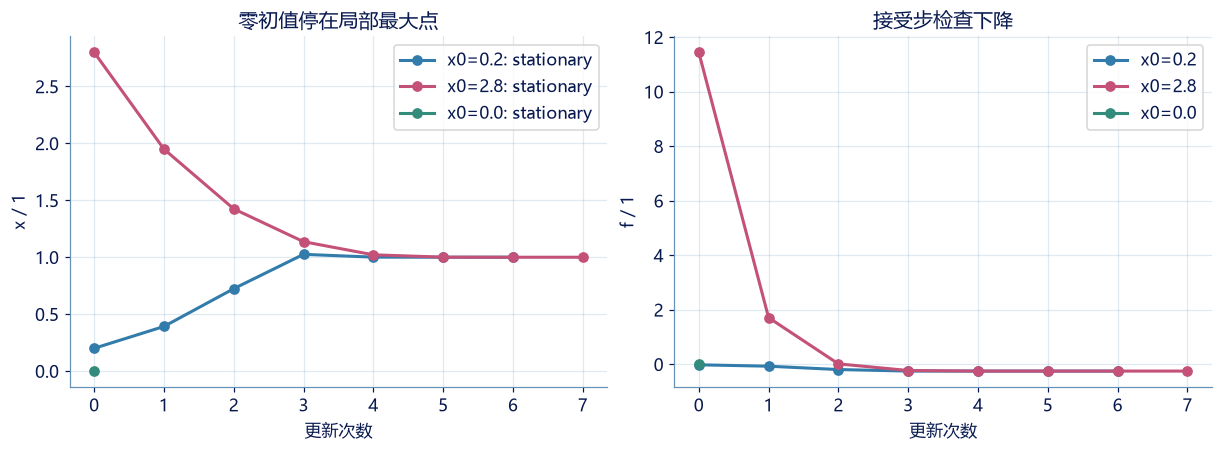

In [4]:
for trials in [0,1,5]:
    print('回溯预算',trials,armijo_quadratic(H.tolist(),[0.,0.],x.tolist(),p.tolist(),1.,.5,.1,trials))
fig,axes=plt.subplots(1,2,figsize=(11,4))
for initial,color in [(.2,BLUE),(2.8,PINK),(0.,GREEN)]:
    history,steps,kinds,status=safeguarded_newton(initial)
    values=np.array(history);objective=values**4/4-values**2/2
    axes[0].plot(values,'o-',label=f'x0={initial}: {status}',color=color)
    axes[1].plot(objective,'o-',label=f'x0={initial}',color=color)
axes[0].set(xlabel='更新次数',ylabel='x / 1',title='零初值停在局部最大点')
axes[1].set(xlabel='更新次数',ylabel='f / 1',title='接受步检查下降');axes[0].legend();axes[1].legend();plt.show()

### 独立核验与边界

In [5]:
g=H@x;limit=-2*(1-.1)*(g@p)/(p@H@p)
accepted=next(t for t in [1.,.5,.25,.125] if t<=limit)
new,t,status=armijo_quadratic(H.tolist(),[0.,0.],x.tolist(),p.tolist(),1.,.5,.1,10)
assert status=='accepted' and t==accepted
for initial in [-2.8,-.2,.2,2.8]:
    history,steps,kinds,status=safeguarded_newton(initial)
    a=np.array(history);assert np.all(np.diff(a**4/4-a**2/2)<=1e-12)
    assert abs(a[-1]**3-a[-1])<=1e-8
assert safeguarded_newton(.2,max_steps=0)[-1]=='max_steps'
assert safeguarded_newton(0.)[-1]=='stationary'
print('解析接受界、有限预算、非凸驻点及每步下降均已核验。')

解析接受界、有限预算、非凸驻点及每步下降均已核验。


## 结果解释

回溯修正的是长度；错误方向要先换掉。四次目标在0处的梯度检查会停止，但目标高于两侧最小值。任何报告都应同时说明停止原因、最后残差、检查尺度和目标假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：返回真正被接受的步长

沿给定方向对严格凸二次目标做有限次数Armijo回溯。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    linear: list[float],
    point: list[float],
    direction: list[float],
    initial_step: float,
    shrink: float,
    slope: float,
    max_trials: int,
) -> tuple[list[float], float | None, str]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | 无量纲 |
| `linear` | `list[float]` | 线性项 b，符号按目标中的减号。 | 无量纲 |
| `point` | `list[float]` | 当前优化变量 x。 | 无量纲 |
| `direction` | `list[float]` | 固定搜索方向p。 | 无量纲 |
| `initial_step` | `float` | 首先尝试的步长t₀。 | 无量纲 |
| `shrink` | `float` | 拒绝一次后步长乘β。 | 无量纲 |
| `slope` | `float` | Armijo系数c。 | 无量纲 |
| `max_trials` | `int` | 最多尝试多少个步长，含t₀。 | 次 |

**返回值**

按以下顺序返回元组：(next_point, accepted_step, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `next_point` | `list[float]` | 接受的点；失败时原点。 | 无量纲 |
| `accepted_step` | <code>float &#124; None</code> | 接受的t，失败时None。 | 无量纲 |
| `status` | `str` | accepted、not_descent或line_search_failed。 | 不适用 |

**计算规则**

先算gᵀp。若≥0返回原点、None、not_descent。依次尝试t₀βʲ，j=0,…,max_trials−1；取第一个满足f(x+tp)≤f(x)+c t gᵀp的t。无接受值返回line_search_failed。

**约束与边界**

- 维数1或2，H正定（positive definite）；0<shrink<1，0<slope<.5；0≤max_trials≤30；所有输入（input）绝对值≤20。
- 初始步长必须严格为正：0<initial_step≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | [[2.0, 0.0], [0.0, 4.0]] | 无量纲 |
| linear | 线性项 b，符号按目标中的减号。 | [0.0, 0.0] | 无量纲 |
| point | 当前优化变量 x。 | [1.0, 1.0] | 无量纲 |
| direction | 固定搜索方向p。 | [-2.0, -4.0] | 无量纲 |
| initial_step | 首先尝试的步长t₀。 | 1 | 无量纲 |
| shrink | 拒绝一次后步长乘β。 | 0.5 | 无量纲 |
| slope | Armijo系数c。 | 0.1 | 无量纲 |
| max_trials | 最多尝试多少个步长，含t₀。 | 5 | 次 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[2.0, 0.0], [0.0, 4.0]]
linear = [0.0, 0.0]
point = [1.0, 1.0]
direction = [-2.0, -4.0]
initial_step = 1.0
shrink = 0.5
slope = 0.1
max_trials = 5

result = solve(matrix, linear, point, direction, initial_step, shrink, slope, max_trials)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| next_point | 接受的点；失败时原点。 | [0.0, -1.0] | 无量纲 |
| accepted_step | 接受的t，失败时None。 | 0.5 | 无量纲 |
| status | accepted、not_descent或line_search_failed。 | accepted | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, -1.0], 0.5, 'accepted')
```

**样例解释**

t=1 不满足充分下降；t=0.5 时 f(x+tp)=2，Armijo 右侧也为 2，等号满足“≤”，故首次接受 t=0.5，新点为 [0,-1]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：返回真正被接受的步长](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-armijo)

### 第 2 题 · 单项选择题：零次尝试是什么

方向已经确认下降，但max_trials=0。应返回什么？

- **A.** 默认接受初始步长。
- **B.** 无接受步长，保持原点并报告line_search_failed。
- **C.** converged。
- **D.** 自动用零步长冒充accepted。

[作答：零次尝试是什么](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-trial-budget)

### 第 3 题 · 多项选择题：步长接受不等于收敛

一次Armijo检验通过，但新点的梯度（gradient）仍明显非零。哪些判断正确？

- **A.** 足以宣布全局最优。
- **B.** 这只说明该次沿该方向满足充分下降。
- **C.** 应在下一迭代重新评估停止条件。
- **D.** 若总更新预算用完，应报告预算耗尽。

[作答：步长接受不等于收敛](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-line-search-status)

### 第 4 题 · 多项选择题：小目标值可信吗

把任意目标f替换为f−10⁶，梯度（gradient）与迭代轨迹（trajectory）保持不变。哪些停止规则仍有相同含义？

- **A.** f<0就停止。
- **B.** 在相同坐标尺度下检查梯度范数（norm）。
- **C.** 严格凸二次问题检查距解析解（analytical solution）的误差。
- **D.** 目标数值越负越接近最优。

[作答：小目标值可信吗](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-objective-offset)

### 第 5 题 · 多项选择题：什么时候小步会被接受

f在当前点附近连续可微，gᵀp<0，0<c<1。无限回溯不断乘0<β<1。哪些结论成立？

- **A.** 充分小的步长会满足Armijo条件。
- **B.** 固定有限max_trials必定足够。
- **C.** 该结论来自一阶余项相对t趋于0。
- **D.** 只要求p非零，不需要方向导数（derivative）为负。

[作答：什么时候小步会被接受](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-search-guarantee)

### 延伸阅读

[Boyd 与 Vandenberghe：《Convex Optimization》](https://web.stanford.edu/~boyd/cvxbook/)，第9章：下降方法与回溯。

[概念探索与交互](http://127.0.0.1:8000/chapters/08-02-梯度、曲率与迭代算法/explore/) · [本篇目录](../README.md)